oversampel used for making balanced data 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.utils import resample
from collections import Counter

In [8]:
x,y = make_classification(n_classes=2, class_sep=2 ,weights= [0.9,0.1],n_informative= 3,n_redundant= 0 
                          ,n_features=5,n_samples=1000,random_state=42)

orignal class distribution Counter({np.int64(0): 894, np.int64(1): 106})


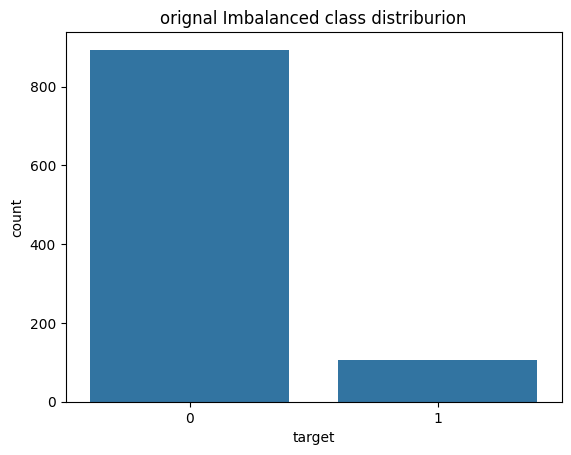

In [7]:
df = pd.DataFrame(x,columns=[f"feature_{i}" for i in range(x.shape[1])])
df['target'] = y 
print("orignal class distribution",Counter(y))
sns.countplot(x=df['target'])
plt.title("orignal Imbalanced class distriburion")
plt.show()

In [13]:
df_majority = df[df['target'] == 0]
df_minority = df[df['target'] == 1]
df_minority_oversampled = resample(df_minority, replace = True, n_samples=len(df_majority),
                                  random_state=42)
df_over = pd.concat([df_majority,df_minority_oversampled])
print("after oversampling :-" ,Counter(df_over['target']))

after oversampling :- Counter({0: 894, 1: 894})


# under sampled

In [19]:
df_majority_undersampled =  resample(df_majority,replace=False,n_samples=len(df_minority),
                                    random_state=42)
df_over_ = pd.concat([df_majority_undersampled,df_minority])
print(Counter(df_over_['target']))

Counter({0: 106, 1: 106})


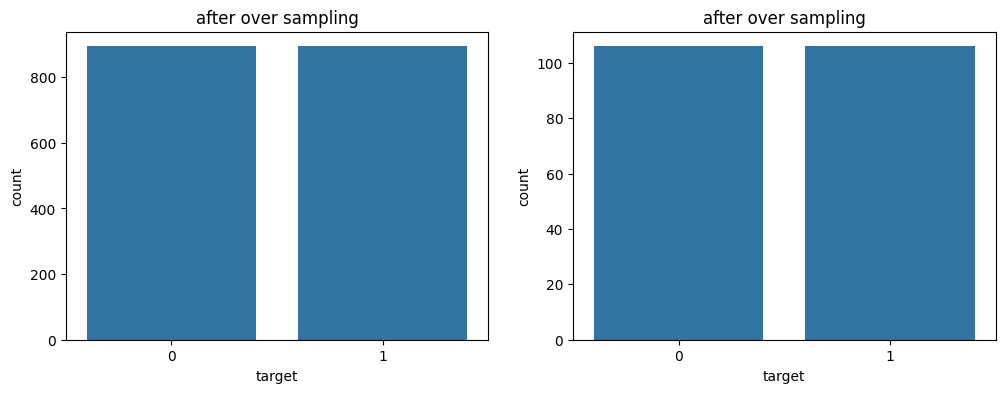

In [32]:
fig, axes = plt.subplots(1,2, figsize = (12,4))
sns.countplot(x= df_over['target'] , ax = axes[0])
axes[0].set_title("after over sampling")


sns.countplot(x= df_over_['target'] , ax = axes[1])
axes[1].set_title("after over sampling")
plt.show()